# Module 7 — Common Experimentation Pitfalls

Part of the **A/B Testing Playbook** learning program. Full program context, progress tracker, and how this module fits with the rest: see `CURRICULUM.md`.

## From the curriculum

> **Concepts**
> - Simpson's paradox and other aggregation traps
> - Novelty and primacy effects — why a metric's short-term movement can mislead about its long-term effect
> - SRM revisited as a pitfall (not just a design-time check)
> - A gallery of real, well-documented experimentation failures at known companies, and what specifically went wrong in each
>
> **Why it matters**
> Module 6 taught you how to analyze *your* results correctly; this module is a catalog so you recognize known failure patterns fast, in your own work and when critiquing someone else's — a very common interview format.
>
> **Worked example**
> Simpson's paradox: overall conversion looks *worse* in treatment than control, but within both mobile and desktop segments, treatment is actually better. The explanation: randomization (or traffic allocation) skewed more low-converting mobile users into treatment, so the segment mix — not the treatment — drove the aggregate number. This is exactly why Module 4's SRM check and segment-consistency checks matter: the aggregate number alone would have led to killing a feature that was actually working.
>
> **Resources**
> - [Seven Rules of Thumb for Web Site Experimenters](https://exp-platform.com/rules-of-thumb/) — Kohavi, Deng, Longbotham, Xu (KDD 2014, verified, free PDF)
>
> **Exercise type:** case-study critique — given a described (real or realistic) experimentation failure, diagnose which pitfall it is and how it should have been caught.
>
> **Interview angle:** "tell me about a time an A/B test result was misleading" / pitfall-recognition questions.

## Lesson

### Simpson's paradox

A result that flips direction depending on whether you look at the aggregate or the segments. It happens when the **mix** between groups differs across control and treatment — not because the treatment behaves differently, but because each group is a different blend of a low-performing and a high-performing segment. The fix isn't a statistical test; it's a habit: whenever a result looks surprising, check whether it holds up **within** the obvious segments, not just in aggregate.

### Novelty and primacy effects

Two mirror-image biases from running a test too short. A **novelty effect**: users react to something *different* out of curiosity, producing a short-term bump that fades as the change stops being new — the early days overstate the true long-run effect. A **primacy effect**: existing users are used to the old way and need time to adjust, producing an initial dip that recovers — the early days *understate* (or even reverse the sign of) the true long-run effect. Both mean the same thing practically: a test's first few days are the least reliable days in the whole run, and stopping early (Module 5's problem again, from a new angle) can read a temporary reaction as the permanent one.

### SRM, revisited

Module 4 built SRM as a design-time check — validate the split before trusting a result. The pitfall here is narrower and easy to miss: **SRM can appear mid-experiment**, from a deploy that changes logging, a bug that only affects one arm, or a targeting rule that correlates with assignment — even when the *totals* still look like a clean 50/50 split. Part 1 below shows a specific case where the overall bucket counts pass an SRM check perfectly while a severe imbalance hides one level down.

### A gallery, grounded in real findings

Kohavi et al.'s paper distills patterns from thousands of real experiments at Amazon, Booking.com, LinkedIn, and Microsoft. A few of their seven rules worth knowing by name: **"changes rarely have a big positive impact — most of your seemingly good results will be false positives"** (a large, surprising win is statistically more likely to be a bug than a breakthrough); **"your mileage will vary"** (a result from a case study or a competitor doesn't transfer to your product without testing it yourself); **"reducing abandonment is hard, shifting clicks is easy"** (a local metric can improve by cannibalizing a different part of the page, with no real gain). Part 3 builds case studies around these patterns — illustrative, not literal retellings of a specific incident, since the paper's exact internal numbers aren't public beyond what's in the citation above.

### Part 1 — Simpson's paradox, fully derived

The curriculum's own worked example, built with real numbers: control skews 80% desktop / 20% mobile, treatment skews the opposite (20% desktop / 80% mobile) — despite the *same* total sample size in each arm. Treatment is genuinely better within both segments.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(3)

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GOOD = "#1a7f37"
BAD = "#cf222e"
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

def z_test_pvalue(x1, n1, x2, n2):
    """Two-proportion z-test p-value -- same formula validated from scratch in Module 3."""
    p1, p2 = x1 / n1, x2 / n2
    p_pooled = (x1 + x2) / (n1 + n2)
    se = np.sqrt(p_pooled * (1 - p_pooled) * (1 / n1 + 1 / n2))
    se_safe = np.where(se == 0, 1, se)
    z = np.where(se == 0, 0, (p2 - p1) / se_safe)
    return 2 * (1 - stats.norm.cdf(np.abs(z)))

In [2]:
n_control, n_treatment = 30_000, 30_000
n_c_desktop, n_c_mobile = int(n_control * 0.8), int(n_control * 0.2)   # control: mostly desktop
n_t_desktop, n_t_mobile = int(n_treatment * 0.2), int(n_treatment * 0.8)  # treatment: mostly mobile

# genuinely better in BOTH segments -- there is a real, positive treatment effect here
c_desktop = rng.binomial(n_c_desktop, 0.08)
t_desktop = rng.binomial(n_t_desktop, 0.095)
c_mobile = rng.binomial(n_c_mobile, 0.03)
t_mobile = rng.binomial(n_t_mobile, 0.037)

p_desktop = z_test_pvalue(c_desktop, n_c_desktop, t_desktop, n_t_desktop)
p_mobile = z_test_pvalue(c_mobile, n_c_mobile, t_mobile, n_t_mobile)
c_total, t_total = c_desktop + c_mobile, t_desktop + t_mobile
p_overall = z_test_pvalue(c_total, n_control, t_total, n_treatment)

table = pd.DataFrame({
    "control rate": [c_desktop/n_c_desktop, c_mobile/n_c_mobile, c_total/n_control],
    "control n": [n_c_desktop, n_c_mobile, n_control],
    "treatment rate": [t_desktop/n_t_desktop, t_mobile/n_t_mobile, t_total/n_treatment],
    "treatment n": [n_t_desktop, n_t_mobile, n_treatment],
    "p-value": [p_desktop, p_mobile, p_overall],
}, index=["Desktop", "Mobile", "OVERALL"])

print(f"Mix check: desktop is {n_c_desktop/n_control:.0%} of control vs. {n_t_desktop/n_treatment:.0%} of treatment -- confirms the mix itself differs, not just the segment results")

table

Mix check: desktop is 80% of control vs. 20% of treatment -- confirms the mix itself differs, not just the segment results


,control rate,control n,treatment rate,treatment n,p-value
Desktop,0.079542,24000,0.093667,6000,0.000371
Mobile,0.028833,6000,0.038250,24000,0.000492
OVERALL,0.069400,30000,0.049333,30000,0.000000


**What this shows:** Desktop and Mobile *each* show treatment significantly better (p < 0.001 both). OVERALL shows treatment significantly *worse* (p ≈ 0) — the exact reversal Simpson's paradox predicts, driven entirely by the mix flip (control mostly desktop, a high-converting segment; treatment mostly mobile, a low-converting one), not by the treatment itself. And the sharpest part: **`n_control` and `n_treatment` are both exactly 30,000** — a standard SRM check on the totals would pass cleanly. The imbalance is entirely one level down, in the segment mix, where a top-level SRM check never looks.

### Part 2 — Novelty and primacy effects, over time

Two simulated 30-day metric trajectories, both converging to the *same* true long-run lift (+2.0pp) — one from above (novelty), one from below (primacy). Stopping after the first 3 days (averaging days 1-3, not just reading day 3 alone) would give a badly wrong read on either one.

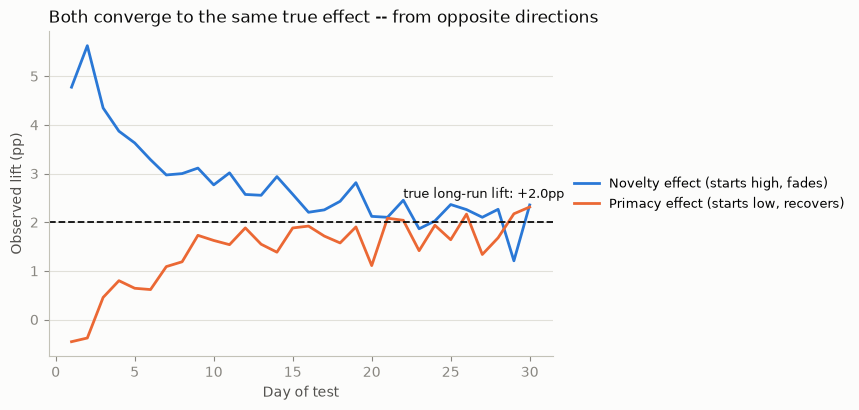

In [3]:
days = np.arange(1, 31)
true_steady_lift = 2.0

novelty_curve = true_steady_lift + 3.5 * np.exp(-days / 7) + rng.normal(0, 0.3, len(days))
primacy_curve = true_steady_lift - 2.5 * np.exp(-days / 7) + rng.normal(0, 0.3, len(days))

fig, ax = plt.subplots(figsize=(8, 4.4), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

ax.plot(days, novelty_curve, color=BLUE, linewidth=2, label="Novelty effect (starts high, fades)")
ax.plot(days, primacy_curve, color=ORANGE, linewidth=2, label="Primacy effect (starts low, recovers)")
ax.axhline(true_steady_lift, color=INK, linewidth=1.3, linestyle="--")
ax.annotate(f"true long-run lift: {true_steady_lift:+.1f}pp", xy=(30, true_steady_lift),
            xytext=(22, true_steady_lift + 0.5), fontsize=9, color=INK)

ax.set_xlabel("Day of test", color=INK_SECONDARY)
ax.set_ylabel("Observed lift (pp)", color=INK_SECONDARY)
ax.set_title("Both converge to the same true effect -- from opposite directions", color=INK, fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED)
ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)

fig.subplots_adjust(left=0.09, right=0.72, top=0.88, bottom=0.14)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
plt.show()

In [4]:
day3_novelty_avg = novelty_curve[:3].mean()
day3_primacy_avg = primacy_curve[:3].mean()
print(f"If stopped after 3 days (average of days 1-3) -- novelty case: read {day3_novelty_avg:+.1f}pp (true: {true_steady_lift:+.1f}pp, overstated by {day3_novelty_avg - true_steady_lift:+.1f}pp)")
print(f"If stopped after 3 days (average of days 1-3) -- primacy case: read {day3_primacy_avg:+.1f}pp (true: {true_steady_lift:+.1f}pp, understated by {day3_primacy_avg - true_steady_lift:+.1f}pp)")

If stopped after 3 days (average of days 1-3) -- novelty case: read +4.9pp (true: +2.0pp, overstated by +2.9pp)
If stopped after 3 days (average of days 1-3) -- primacy case: read -0.1pp (true: +2.0pp, understated by -2.1pp)


**What this shows:** the 3-day-average read is off by more than two full points in both directions — in the novelty case, enough to make a merely-good change look like a huge win; in the primacy case, enough to make a genuinely positive change look flat or negative on day 1 (the primacy curve actually starts *negative* here). Neither bias announces itself — both curves look like a perfectly normal, statistically clean result on any single day. The only real defense is running long enough to watch the curve settle, not just checking whether an early day is significant.

### Part 3 — Gallery: three case studies, worked

Each grounded in a real pattern from the Kohavi et al. paper (cited above) — illustrative scenarios built around verified, documented findings, not claimed as literal blow-by-blow incident transcripts.

**Case A — the overnight 40% lift**

> A copy tweak on the checkout page shows a 40% lift in completed purchases after one day. The team is ready to ship immediately.

**Pitfall:** this is Kohavi et al.'s Rule 2 in action — *"changes rarely have a big positive impact on key metrics... most of your seemingly good results will be false positives."* A 40% lift from a copy tweak is far outside the range genuine UI changes normally produce. **How it should be caught:** treat a surprisingly large win as a *bug signal* first, not a cause for celebration — check for an SRM issue, a logging bug (e.g. double-counting purchases in one arm), or an instrumentation error before trusting the number. The size of the win is itself the red flag.

**Case B — the button that won, the page that didn't**

> A redesigned "Add to cart" button increases clicks on that button by 25%. Overall purchases are flat.

**Pitfall:** Rule 5 — *"reducing abandonment is hard, shifting clicks is easy."* The button won a *local* metric by pulling clicks from somewhere else on the page (a promo banner, a related-items link), not by creating new purchase intent. **How it should be caught:** always pair a local/proxy metric (button clicks) with a global one (overall purchases, Module 2's leading-vs-lagging distinction) — a local win with a flat global metric is redistribution, not growth.

**Case C — the SRM that showed up on day 4**

> An experiment passes its SRM check at launch (clean 50/50 split). On day 4, a caching change is deployed to *only* the treatment arm. The team doesn't re-check SRM, since "it already passed."

**Pitfall:** SRM revisited, from the lesson above. SRM is a *design-time* check by default, but bugs that break random assignment or logging can land *during* a live test. **How it should be caught:** monitor SRM continuously (or at each scheduled check, alongside guardrails — Module 5's exception) rather than treating the launch-time check as a one-time clearance that covers the whole run.

## Key takeaways

- A surprising aggregate result should always be checked against the obvious segments — Simpson's paradox can flip a genuinely positive effect into an apparent loss purely from mix shift, and can hide underneath a perfectly clean top-level SRM check
- A test's first few days are its least reliable — novelty and primacy effects bias early reads in opposite directions, and both look statistically unremarkable while they're happening
- SRM isn't a one-time launch check — assignment and logging can break mid-experiment
- The single best guard against most of this gallery: be *more* skeptical of a big, exciting win than of a null result — real effects are usually modest, and modest is what Module 3's power calculations were sized around in the first place

---
*Status: mark this module's row in `CURRICULUM.md`'s progress table once reviewed.*